In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [2]:
def load_results(path):
    df = pd.read_csv(path)

    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    for col in df.columns:
        if col.endswith("_all"):
            df[col] = (
                df[col]
                .str.replace('[', '')
                .str.replace(']', '')
                .apply(lambda x: [float(v) for v in x.split()])
            )
    return df

def to_long_balanced(df, balanced, metric="F1_macro"):
    rows = []

    for _, row in df.iterrows():
        model = row["Model"]
        scores = row[f"CV_{metric}_all"]

        for s in scores:
            rows.append({
                "Balanced": balanced,
                "Model": model,
                metric: s
            })

    return pd.DataFrame(rows)

## PlayStoreReviews

### Balanced BoW

In [3]:
paths = {
    "BASE_TEXT": "../../data/out/baseline/baseline_08_PlayStoreReviews_BoW.csv",
    "TEXT_LEMMA": "../../data/out/preprocess/preprocess_08_PlayStoreReviews_BoW_TEXT_NO_STOP.csv",
    "TEXT_LEMMA_SMOTE": "../../data/out/balanced/balanced_08_PlayStoreReviews_BoW.csv",
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_balanced(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("Balanced")
    .head(df_long.groupby("Balanced").size().min())
    .reset_index(drop=True)
)

baseline = "BASE_TEXT"
balances = df_pair["Balanced"].unique()
balances = [p for p in balances if p != baseline]

results = []

scores_base = (
    df_pair[df_pair["Balanced"] == baseline]["F1_macro"]
    .to_numpy()
)

n = len(scores_base)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

for prep in balances:
    scores_other = (
        df_pair[df_pair["Balanced"] == prep]["F1_macro"]
        .to_numpy()
    )

    stat, p = wilcoxon(scores_base, scores_other)

    z = (stat - mean_w) / std_w
    r = abs(z) / np.sqrt(n)

    results.append({
        "Comparison": f"{baseline} vs {prep}",
        "Wilcoxon_stat": stat,
        "p_value": p,
        "Z": z,
        "Effect_size_r": r
    })

df_wilcoxon = pd.DataFrame(results)
df_wilcoxon.style.hide(axis="index")

Comparison,Wilcoxon_stat,p_value,Z,Effect_size_r
BASE_TEXT vs TEXT_LEMMA,4703.000000,0.071821,-1.800252,0.146990
BASE_TEXT vs TEXT_LEMMA_SMOTE,1681.000000,0.000000,-7.470247,0.609943


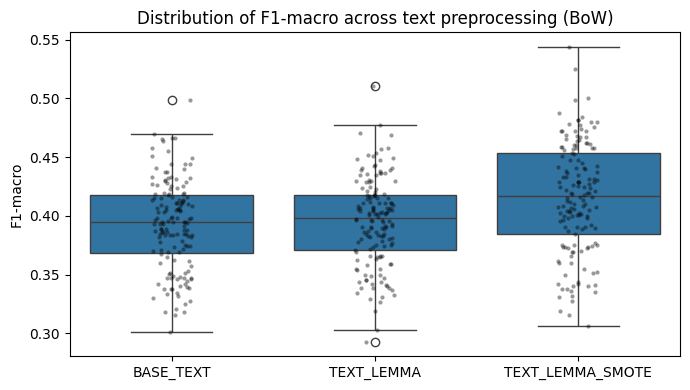

In [5]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_long,
    x="Balanced",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Balanced",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro across text preprocessing (BoW)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Balanced TFIDF

In [6]:
paths = {
    "BASE_TEXT": "../../data/out/baseline/baseline_08_PlayStoreReviews_TFIDF.csv",
    "TEXT_LEMMA": "../../data/out/preprocess/preprocess_08_PlayStoreReviews_TFIDF_TEXT_NO_STOP.csv",
    "TEXT_LEMMA_SMOTE": "../../data/out/balanced/balanced_08_PlayStoreReviews_TFIDF.csv",
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_balanced(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("Balanced")
    .head(df_long.groupby("Balanced").size().min())
    .reset_index(drop=True)
)

baseline = "BASE_TEXT"
balances = df_pair["Balanced"].unique()
balances = [p for p in balances if p != baseline]

results = []

scores_base = (
    df_pair[df_pair["Balanced"] == baseline]["F1_macro"]
    .to_numpy()
)

n = len(scores_base)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

for prep in balances:
    scores_other = (
        df_pair[df_pair["Balanced"] == prep]["F1_macro"]
        .to_numpy()
    )

    stat, p = wilcoxon(scores_base, scores_other)

    z = (stat - mean_w) / std_w
    r = abs(z) / np.sqrt(n)

    results.append({
        "Comparison": f"{baseline} vs {prep}",
        "Wilcoxon_stat": stat,
        "p_value": p,
        "Z": z,
        "Effect_size_r": r
    })

df_wilcoxon = pd.DataFrame(results)
df_wilcoxon.style.hide(axis="index")

Comparison,Wilcoxon_stat,p_value,Z,Effect_size_r
BASE_TEXT vs TEXT_LEMMA,3588.000000,0.000099,-3.892259,0.317802
BASE_TEXT vs TEXT_LEMMA_SMOTE,291.000000,0.000000,-10.078220,0.822883


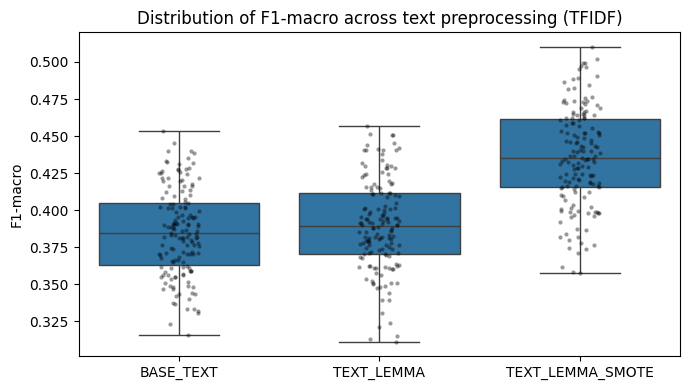

In [8]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_long,
    x="Balanced",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Balanced",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro across text preprocessing (TFIDF)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()